# Get the data

In [27]:
import pandas as pd
from sklearn.datasets import load_wine


wine = load_wine()

X = wine.data   
y = wine.target

print(X.shape, y.shape)

(178, 13) (178,)


# Split the data

In [28]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Shape of train: {X_train.shape}, {y_train.shape}")
print(f"Shape of test: {X_test.shape}, {y_test.shape}")

Shape of train: (142, 13), (142,)
Shape of test: (36, 13), (36,)


# Verify the values counts in train

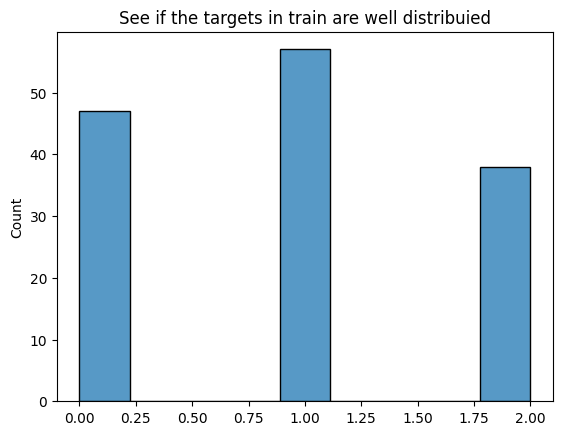

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y_train)
plt.title(f"See if the targets in train are well distribuied")
plt.show()

# Get the model

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV

models = [DecisionTreeClassifier(), RandomForestClassifier(), SVC()]

# Get the metrics

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay


DecisionTreeClassifier
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:0.972 | F1: 0.974 | Precision: 0.974 | Recall: 0.976 | 
Confusion Matriz:


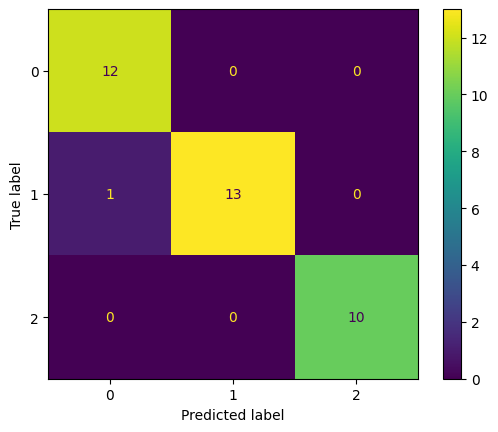

Best Parâmetros: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Melhor Score (CV F1-Macro): 0.943
RandomForestClassifier
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000 | 
Confusion Matriz:


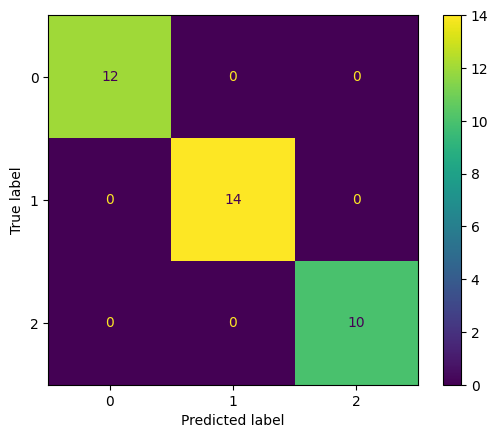

Best Parâmetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Melhor Score (CV F1-Macro): 0.993
SVC
Train Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000|
Test Metrics: Accuracy:0.944 | F1: 0.945 | Precision: 0.951 | Recall: 0.943 | 
Confusion Matriz:


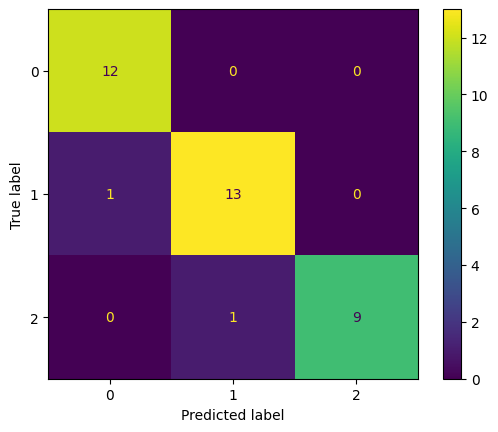

Best Parâmetros: {'kernel': 'linear'}
Melhor Score (CV F1-Macro): 0.986


In [39]:
for model in models:

    if model.__class__.__name__ == "DecisionTreeClassifier":
          params = {
    'max_depth': [None, 5, 10],          
    'min_samples_split': [2, 5],         
    'criterion': ['gini', 'entropy'],    
    'class_weight': ['balanced']}
    elif model.__class__.__name__ == 'RandomForestClassifier':
         params = {
    'n_estimators': [50, 100, 200],      
    'max_depth': [None, 5, 10],          
    'min_samples_split': [2, 5],         
    'criterion': ['gini', 'entropy'],    
    'class_weight': ['balanced']}
    else:
        params = {
             "kernel": ['linear', 'rbf', 'sigmoid']}

    print('=' * 50)
    print(f'{model.__class__.__name__}')

    pipe = Pipeline(
        steps=[
             ("Scaler", StandardScaler()), 
            ("Model", GridSearchCV(estimator=model, param_grid=params, cv=5, n_jobs=-1))
            ]
        )
    

    pipe.fit(X_train, y_train)

    # Val Score
    y_preds_train = pipe.predict(X_train)
    accuracy = accuracy_score(y_train, y_preds_train)
    f1 = f1_score(y_train, y_preds_train, average = 'macro')
    precision = precision_score(y_train, y_preds_train, average = 'macro')
    recall = recall_score(y_train, y_preds_train, average = 'macro')
    print(f"Train Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}|")

    # See the metrics (test set)
    y_preds_test = pipe.predict(X_test)
    accuracy = accuracy_score(y_test, y_preds_test)
    f1 = f1_score(y_test, y_preds_test, average = 'macro')
    precision = precision_score(y_test, y_preds_test, average = 'macro')
    recall = recall_score(y_test, y_preds_test, average = 'macro')
    confusion_m = ConfusionMatrixDisplay.from_predictions(y_test, y_preds_test)
    print(f"Test Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | \nConfusion Matriz:")
    plt.show()

    print(f"Best Parâmetros: {pipe[1].best_params_}")
    print(f"Melhor Score (CV F1-Macro): {pipe[1].best_score_:.3f}")

